# Plate to Bin: where does a hostel mess's food go?

A 1,200-student hostel mess cooks about **1.2 tonnes of food a day**. The mess committee knew some of it was thrown away but not how much, when, or why, and students kept complaining that the good dishes ran out.

**The questions I set out to answer**
1. How much food is wasted, and what does it cost?
2. Is it a *cooking* problem (too much made) or an *eating* problem (food left on plates)?
3. Which days, meals, events and dishes drive it?
4. Did the weekend-breakfast opt-in pilot started in Feb 2026 actually work?
5. What should the mess change, and how much would that save?

> **About the data:** mess records aren't public, so the dataset is simulated from documented assumptions (`src/simulate_data.py`) and deliberately left messy. The same notebook runs unchanged on real data with the same columns.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# One palette for the whole project
LEFTOVER, PLATE, STEEL, LEAF, INK = "#D4962A", "#B5452F", "#6B7780", "#4E7D4A", "#2B2B2B"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left",
    "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
})
pd.set_option("display.float_format", "{:,.1f}".format)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")

## 1. First look at the raw kitchen log

Before trusting any number I checked what the log actually looks like.

In [2]:
raw = pd.read_csv(ROOT / "data/raw/meal_log_raw.csv")
print(raw.shape)
raw.head()

(726, 9)


,date,meal_type,dish_name,students_registered,headcount,food_prepared_kg,leftover_kg,plate_waste_kg,ran_out
0,2025-11-02,breakfast,Poha,1200,363,276.7,165.0,8.9,N
1,2025-08-18,dinner,Mixed Veg,1200,997,499.9,54.1,64.5,N
2,2025-10-05,dinner,Chicken Curry,1200,773,479.5,154.1,7.0,N
3,2025-10-01,breakfast,Poha,1200,901,278.4,33.4,21.7,N
4,2026-01-14,dinner,Egg Curry,1200,1014,476.8,24.9,19.9,N


In [3]:
issues = {
    "dates not in YYYY-MM-DD": (~raw["date"].str.match(r"^\d{4}-\d{2}-\d{2}$")).sum(),
    "meal_type spellings": raw["meal_type"].nunique(),
    "dish name spellings (22 real dishes)": raw["dish_name"].nunique(),
    "exact duplicate rows": raw.duplicated().sum(),
    "missing plate_waste_kg": raw["plate_waste_kg"].isna().sum(),
    "leftover > food prepared (impossible)": (raw["leftover_kg"] > raw["food_prepared_kg"]).sum(),
}
pd.Series(issues, name="count").to_frame()

,count
dates not in YYYY-MM-DD,28
meal_type spellings,9
dish name spellings (22 real dishes),26
exact duplicate rows,12
missing plate_waste_kg,17
leftover > food prepared (impossible),6


Six kinds of problems. The impossible leftovers turned out to be values typed in grams (e.g. 48,300 instead of 48.3), and the missing plate-waste values line up with days the weighing scale wasn't working.
All fixes live in `src/clean_data.py` so they're repeatable; missing plate waste is filled with **that dish's** median waste share rather than a global average, because dishes differ a lot.

In [4]:
%run ../src/clean_data.py

Cleaning report
----------------------------------------
 • Dates written as DD-MM-YYYY fixed: 28
 • Dish name variants merged: 26 -> 22
 • Duplicate rows removed: 12
 • Leftover values entered in grams converted to kg: 6
 • Missing plate-waste values imputed (dish median): 17

Final table: 714 meals, 23 columns -> data/processed/meals_clean.csv


In [5]:
meals = pd.read_csv(ROOT / "data/processed/meals_clean.csv", parse_dates=["date"])
feedback = pd.read_csv(ROOT / "data/processed/feedback_clean.csv", parse_dates=["date"])
meal_order = ["breakfast", "lunch", "dinner"]
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
meals["meal_type"] = pd.Categorical(meals["meal_type"], meal_order, ordered=True)
meals.head(3)

,date,meal_type,dish_name,students_registered,headcount,food_prepared_kg,leftover_kg,plate_waste_kg,ran_out,served_kg,...,cost_per_kg,day_of_week,academic_event,weather,total_waste_kg,waste_pct,attendance_pct,waste_cost_inr,is_weekend,month
0,2025-07-21,breakfast,Poha,1200,776,254.6,28.2,15.2,False,226.4,...,48,Monday,regular,clear,43.4,17.1,64.7,"2,083.0",False,2025-07
1,2025-07-21,lunch,Rajma Chawal,1200,963,453.0,24.2,34.2,False,428.8,...,70,Monday,regular,clear,58.4,12.9,80.2,"4,088.0",False,2025-07
2,2025-07-21,dinner,Chole Bhature,1200,1048,500.8,39.6,15.8,False,461.2,...,78,Monday,regular,clear,55.4,11.1,87.3,"4,321.0",False,2025-07


## 2. How big is the problem?

In [6]:
cooked, wasted = meals["food_prepared_kg"].sum(), meals["total_waste_kg"].sum()
kpi = pd.Series({
    "Days the mess was open": meals["date"].nunique(),
    "Food cooked (tonnes)": cooked / 1000,
    "Food wasted (tonnes)": wasted / 1000,
    "Share of food wasted (%)": wasted / cooked * 100,
    "Cost of waste (₹ lakh)": meals["waste_cost_inr"].sum() / 1e5,
    "Cost of waste per student (₹)": meals["waste_cost_inr"].sum() / 1200,
    "Meals where food ran out": meals["ran_out"].sum(),
})
kpi.to_frame("value")

,value
Days the mess was open,238.0
Food cooked (tonnes),285.7
Food wasted (tonnes),67.0
Share of food wasted (%),23.5
Cost of waste (₹ lakh),46.5
Cost of waste per student (₹),"3,870.9"
Meals where food ran out,101.0


**Almost a quarter of everything cooked is thrown away**, roughly ₹46 lakh over eight months. And yet in about 1 meal out of 7 the food *ran out*. The mess has two problems at the same time, which is a clue that the issue is planning, not quantity.

## 3. Cooking problem or eating problem?

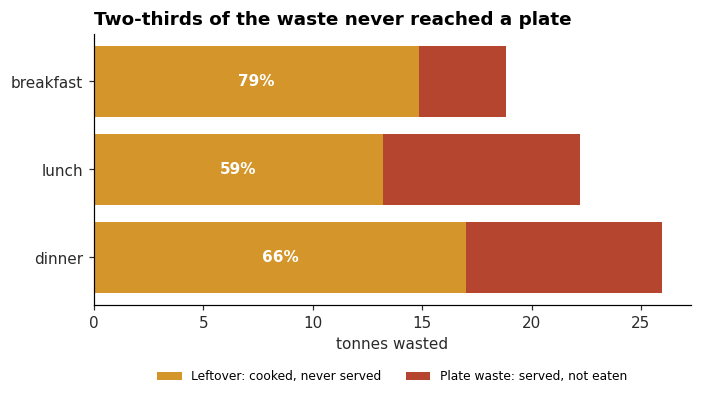

In [7]:
split = meals.groupby("meal_type", observed=True)[["leftover_kg", "plate_waste_kg"]].sum() / 1000

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(split.index, split["leftover_kg"], color=LEFTOVER, label="Leftover: cooked, never served")
ax.barh(split.index, split["plate_waste_kg"], left=split["leftover_kg"], color=PLATE,
        label="Plate waste: served, not eaten")
for i, (lo, pw) in enumerate(split.values):
    ax.text(lo / 2, i, f"{lo / (lo + pw):.0%}", va="center", ha="center", color="white", fontweight="bold")
ax.invert_yaxis()
ax.set_xlabel("tonnes wasted")
ax.set_title("Two-thirds of the waste never reached a plate")
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=8)
save(fig, "01_leftover_vs_plate_waste")
plt.show()

About **two-thirds of the waste is leftover food** that was cooked and never served. That's a forecasting problem the kitchen can fix without changing a single recipe. Plate waste is the smaller, harder part (taste and portion size).

## 4. When does the kitchen over-cook?

The kitchen's rule is fixed: cook for a set share of the 1,200 registered students plus an 8% buffer, every day. Attendance isn't fixed. I'm using data **before** the Feb-2026 pilot here so the pilot doesn't hide the pattern.

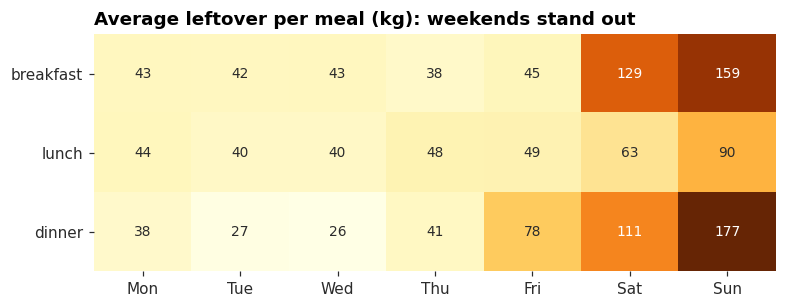

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
meal_type,,,,,,,
breakfast,62.0,63.0,63.0,63.0,63.0,35.0,27.0
lunch,78.0,80.0,79.0,77.0,77.0,73.0,66.0
dinner,84.0,86.0,86.0,83.0,77.0,67.0,55.0


In [8]:
pre = meals[meals["date"] < "2026-02-01"]
heat = pre.pivot_table(index="meal_type", columns="day_of_week", values="leftover_kg",
                       aggfunc="mean", observed=True)[day_order]

fig, ax = plt.subplots(figsize=(8, 2.8))
im = ax.imshow(heat.values, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(7), [d[:3] for d in day_order]); ax.set_yticks(range(3), heat.index)
for (i, j), v in np.ndenumerate(heat.values):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", color="white" if v > 100 else INK, fontsize=9)
ax.set_title("Average leftover per meal (kg): weekends stand out")
ax.spines[:].set_visible(False)
save(fig, "02_leftover_heatmap")
plt.show()

pre.pivot_table(index="meal_type", columns="day_of_week", values="attendance_pct",
                observed=True)[day_order].round(0)

**Saturday and Sunday breakfast** attendance falls to roughly 30% (students sleep in) while the kitchen still cooks for ~70%, so about 130 to 160 kg goes in the bin each time. **Sunday dinner** shows the same pattern, as many students order food from outside.

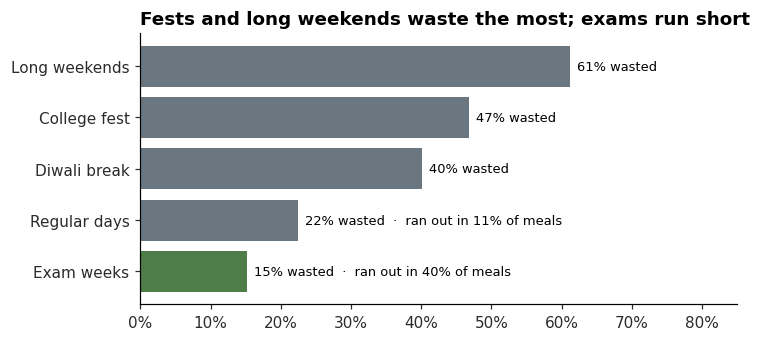

,attendance,waste_pct,ran_out
academic_event,,,
exams,81.3,15.2,39.6
regular,71.8,22.4,10.7
diwali_break,16.9,40.1,0.0
fest,49.0,46.8,0.0
long_weekend,36.3,61.2,0.0


In [9]:
ev = (meals.groupby("academic_event")
      .agg(attendance=("attendance_pct", "mean"),
           waste_pct=("total_waste_kg", lambda s: s.sum() / meals.loc[s.index, "food_prepared_kg"].sum() * 100),
           ran_out=("ran_out", "mean"))
      .sort_values("waste_pct"))
ev["ran_out"] *= 100
labels = {"exams": "Exam weeks", "regular": "Regular days", "diwali_break": "Diwali break",
          "fest": "College fest", "long_weekend": "Long weekends"}

fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(ev))
ax.barh(y, ev["waste_pct"], color=[LEAF if e == "exams" else STEEL for e in ev.index])
ax.set_yticks(y, [labels[e] for e in ev.index])
for i, (w, r) in enumerate(zip(ev["waste_pct"], ev["ran_out"])):
    ax.text(w + 1, i, f"{w:.0f}% wasted" + (f"  ·  ran out in {r:.0f}% of meals" if r else ""),
            va="center", fontsize=8.5)
ax.set_xlim(0, 85); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Fests and long weekends waste the most; exams run short")
save(fig, "03_events")
plt.show()
ev

The kitchen adjusts for Diwali but not for anything else on the academic calendar. During the **college fest and long weekends**, half or more of the food is wasted. During **exams** students stay in, waste drops to ~15%, and food runs out in about 4 meals out of 10. The academic calendar is published months in advance, so this is avoidable.

In [10]:
reg = meals[(meals["academic_event"] == "regular") & (meals["meal_type"] != "breakfast")]
reg.groupby("weather")[["attendance_pct", "ran_out"]].mean().assign(ran_out=lambda d: d.ran_out * 100)

,attendance_pct,ran_out
weather,,
clear,78.6,9.9
rain,86.9,40.3


Rain matters too: on rainy days lunch and dinner attendance rises by about 8 points and food runs out four times as often, because nobody walks out to eat.

## 5. Which dishes are the problem?

Two different failures: dishes students **leave on the plate**, and dishes that **run out**. Plotting both together sorts the menu into actions.

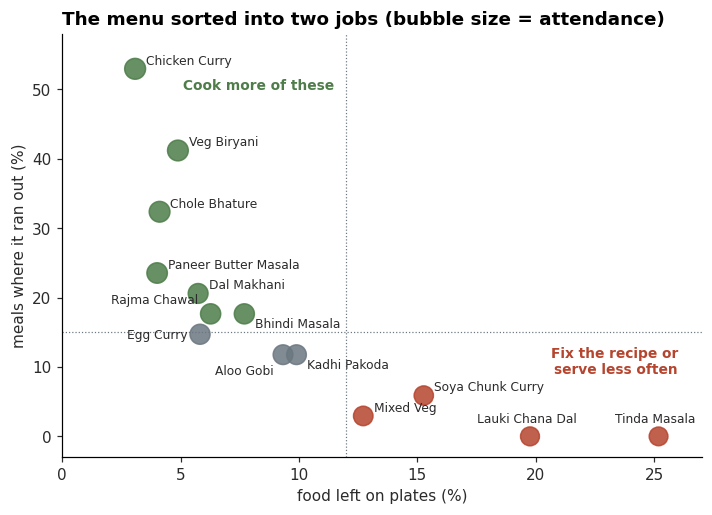

,plate_waste_pct,attendance_pct,slot,ran_out_pct
dish_name,,,,
Tinda Masala,25.2,67.8,lunch/dinner,0.0
Lauki Chana Dal,19.8,69.3,lunch/dinner,0.0
Upma,18.7,48.8,breakfast,NaN
Vermicelli Upma,16.7,52.7,breakfast,NaN
Soya Chunk Curry,15.3,72.0,lunch/dinner,5.9
Mixed Veg,12.7,73.6,lunch/dinner,2.9
Kadhi Pakoda,9.9,75.2,lunch/dinner,11.8
Aloo Gobi,9.3,75.3,lunch/dinner,11.8


In [11]:
mains = meals[meals["meal_type"] != "breakfast"]
dish = (meals.groupby("dish_name")
        .apply(lambda g: pd.Series({
            "plate_waste_pct": g.plate_waste_kg.sum() / g.served_kg.sum() * 100,
            "attendance_pct": g.attendance_pct.mean(),
            "slot": "breakfast" if (g.meal_type == "breakfast").all() else "lunch/dinner"}), include_groups=False))
dish["ran_out_pct"] = mains.groupby("dish_name")["ran_out"].mean() * 100

d = dish[dish["slot"] == "lunch/dinner"]
fig, ax = plt.subplots(figsize=(7.5, 5))
colors = np.where(d["ran_out_pct"] > 15, LEAF, np.where(d["plate_waste_pct"] > 12, PLATE, STEEL))
ax.scatter(d["plate_waste_pct"], d["ran_out_pct"], s=d["attendance_pct"] * 2.2, c=colors, alpha=.85)
nudge = {"Rajma Chawal": (-8, 7, "right"), "Bhindi Masala": (7, -9, "left"),
         "Aloo Gobi": (-6, -13, "right"), "Kadhi Pakoda": (7, -9, "left"),
         "Egg Curry": (-8, -3, "right"), "Lauki Chana Dal": (-2, 9, "center"),
         "Tinda Masala": (-2, 9, "center")}
for name, r in d.iterrows():
    dx, dy, ha = nudge.get(name, (7, 3, "left"))
    ax.annotate(name, (r.plate_waste_pct, r.ran_out_pct), xytext=(dx, dy),
                textcoords="offset points", fontsize=8, color=INK, ha=ha)
ax.axvline(12, color=STEEL, lw=.8, ls=":"); ax.axhline(15, color=STEEL, lw=.8, ls=":")
ax.text(11.5, 50, "Cook more of these", ha="right", color=LEAF, fontweight="bold", fontsize=9)
ax.text(26, 9, "Fix the recipe or\nserve less often", ha="right", color=PLATE, fontweight="bold", fontsize=9)
ax.set_xlabel("food left on plates (%)"); ax.set_ylabel("meals where it ran out (%)")
ax.set_xlim(0, 27); ax.set_ylim(-3, 58)
ax.set_title("The menu sorted into two jobs (bubble size = attendance)")
save(fig, "04_dish_quadrant")
plt.show()
dish.sort_values("plate_waste_pct", ascending=False).head(8)

- **Cook more:** Chicken Curry, Veg Biryani and Chole Bhature run out in a third to a half of the meals they're served, because they also pull the most students in. The fixed cooking rule ignores that.
- **Fix or rotate out:** Tinda Masala and Lauki Chana Dal lose a fifth to a quarter of every plate. Upma does the same at breakfast.

## 6. Can student ratings warn us early?

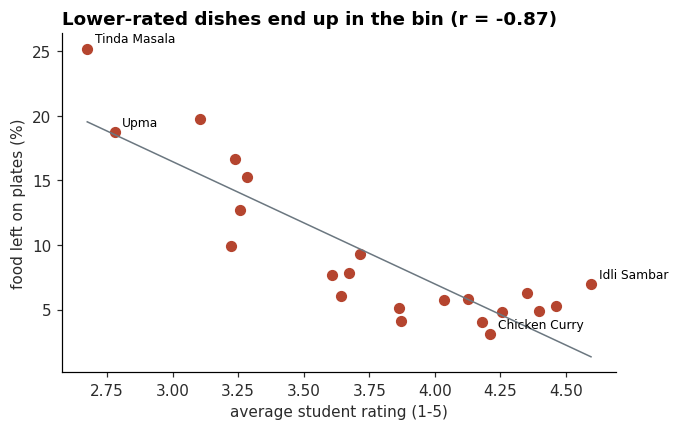

Correlation between rating and plate waste: -0.87  |  ratings collected: 7,002


In [12]:
fb = feedback.merge(meals[["date", "meal_type", "dish_name"]].astype({"meal_type": str}),
                    on=["date", "meal_type"])
rated = fb.groupby("dish_name")["rating"].mean().to_frame("avg_rating").join(dish)
r = rated["avg_rating"].corr(rated["plate_waste_pct"])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(rated["avg_rating"], rated["plate_waste_pct"], color=PLATE, s=40)
m, b = np.polyfit(rated["avg_rating"], rated["plate_waste_pct"], 1)
xs = np.linspace(rated["avg_rating"].min(), rated["avg_rating"].max(), 50)
ax.plot(xs, m * xs + b, color=STEEL, lw=1)
for name in ["Tinda Masala", "Upma", "Chicken Curry", "Idli Sambar"]:
    ax.annotate(name, (rated.loc[name, "avg_rating"], rated.loc[name, "plate_waste_pct"]),
                xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("average student rating (1-5)"); ax.set_ylabel("food left on plates (%)")
ax.set_title(f"Lower-rated dishes end up in the bin (r = {r:.2f})")
save(fig, "05_rating_vs_waste")
plt.show()
print(f"Correlation between rating and plate waste: {r:.2f}  |  ratings collected: {len(feedback):,}")

A strong negative relationship (r ≈ −0.87): the QR-code ratings, which only about 1% of students fill in, are already a reliable early signal. A new dish that rates below ~3.3 in its first two weeks is likely to become a plate-waste problem.

*Correlation isn't causation here: portion size and habit also drive plate waste, which is why a few dishes sit off the line.*

## 7. Did the opt-in pilot work?

From **1 Feb 2026** students had to tap "I'm coming" by 10 pm the night before **weekend breakfasts**, and the kitchen cooked for those numbers. A simple before/after would be misleading because February and March also have exams, a fest and Holi. So I compare the change in weekend breakfasts with the change in **weekday breakfasts** (which had no pilot) over the same months. This is a basic *difference-in-differences*.

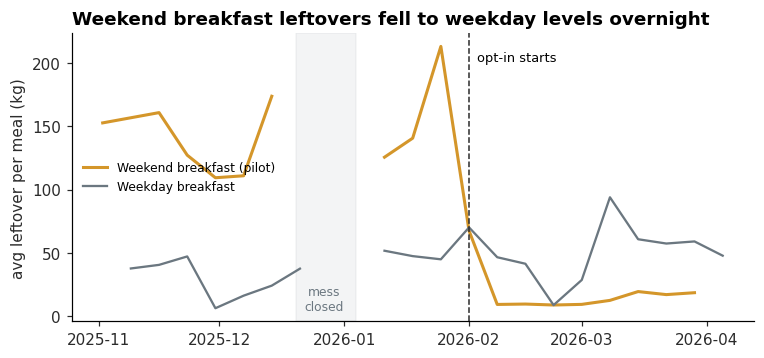

Estimated effect of the pilot: 143 kg less leftover per weekend breakfast


period,Before,After,Change
group,,,
Weekday (no change),38.6,49.5,10.9
Weekend (pilot),145.5,13.4,-132.1


In [13]:
b = meals[(meals["meal_type"] == "breakfast") & (meals["date"] >= "2025-11-01")].copy()
b["group"] = np.where(b["is_weekend"], "Weekend (pilot)", "Weekday (no change)")
b["period"] = np.where(b["date"] >= "2026-02-01", "After", "Before")
did = b.pivot_table(index="group", columns="period", values="leftover_kg")[["Before", "After"]]
did["Change"] = did["After"] - did["Before"]
effect = did.loc["Weekend (pilot)", "Change"] - did.loc["Weekday (no change)", "Change"]

wk = (b.set_index("date").groupby("group")["leftover_kg"].resample("W").mean().unstack(0))
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(wk.index, wk["Weekend (pilot)"], color=LEFTOVER, lw=2, label="Weekend breakfast (pilot)")
ax.plot(wk.index, wk["Weekday (no change)"], color=STEEL, lw=1.5, label="Weekday breakfast")
ax.axvline(pd.Timestamp("2026-02-01"), color=INK, ls="--", lw=1)
ax.text(pd.Timestamp("2026-02-03"), ax.get_ylim()[1] * .9, "opt-in starts", fontsize=8.5)
ax.axvspan(pd.Timestamp("2025-12-20"), pd.Timestamp("2026-01-04"), color=STEEL, alpha=.08)
ax.text(pd.Timestamp("2025-12-27"), 5, "mess\nclosed", ha="center", fontsize=8, color=STEEL)
ax.set_ylabel("avg leftover per meal (kg)")
ax.set_title("Weekend breakfast leftovers fell to weekday levels overnight")
ax.legend(frameon=False, fontsize=8, loc="center left")
save(fig, "06_pilot_did")
plt.show()

print(f"Estimated effect of the pilot: {abs(effect):,.0f} kg less leftover per weekend breakfast")
did

Weekday breakfasts got slightly *worse* after February (the exam and Holi effect), while weekend breakfasts dropped by ~130 kg. Netting out that background change, the pilot cut leftovers by about **140 kg per weekend breakfast**, which is roughly 90%.

*Caveat: about 17 pilot breakfasts in the data. That's enough to see a large effect, but worth re-checking after a full semester.*

## 8. What would the fixes save?

Conservative estimates, priced at each dish's cost per kg, for one academic year (~238 open days, the same as this dataset).

In [14]:
before = meals[meals["date"] < "2026-02-01"]
avg_cost = lambda df: (df["waste_cost_inr"] / df["total_waste_kg"]).mean()

# 1) Opt-in for weekend breakfast + Sunday dinner: bring leftovers down to the weekday average
wk_bf = before[(before.meal_type == "breakfast") & before.is_weekend]
wd_bf = before[(before.meal_type == "breakfast") & ~before.is_weekend]
sun_dn = before[(before.meal_type == "dinner") & (before.day_of_week == "Sunday")]
wd_dn = before[(before.meal_type == "dinner") & ~before.is_weekend]
s1 = ((wk_bf.leftover_kg.mean() - wd_bf.leftover_kg.mean()) * 2 * 34 * avg_cost(wk_bf)
      + (sun_dn.leftover_kg.mean() - wd_dn.leftover_kg.mean()) * 34 * avg_cost(sun_dn))

# 2) Calendar-aware cooking: on fest and long-weekend days, cut leftover by half
ev_days = meals[meals.academic_event.isin(["fest", "long_weekend"])]
s2 = (ev_days.leftover_kg * 0.5 * ev_days.cost_per_kg).sum()

# 3) Fix or halve the frequency of the 4 worst plate-waste dishes: cut their plate waste by 40%
worst = dish.sort_values("plate_waste_pct", ascending=False).head(4).index
w = meals[meals.dish_name.isin(worst)]
s3 = (w.plate_waste_kg * 0.40 * w.cost_per_kg).sum()

savings = pd.DataFrame({
    "change": ["Opt-in for weekend breakfast & Sunday dinner",
               "Cook to the academic calendar (fests, long weekends)",
               "Rework or rotate out the 4 most-wasted dishes"],
    "saving_inr_lakh": [s1 / 1e5, s2 / 1e5, s3 / 1e5],
})
savings.loc[len(savings)] = ["Total", savings.saving_inr_lakh.sum()]
savings["share_of_current_waste_%"] = savings.saving_inr_lakh / (meals.waste_cost_inr.sum() / 1e5) * 100
savings

,change,saving_inr_lakh,share_of_current_waste_%
0,Opt-in for weekend breakfast & Sunday dinner,7.9,16.9
1,"Cook to the academic calendar (fests, long wee...",3.4,7.3
2,Rework or rotate out the 4 most-wasted dishes,1.5,3.3
3,Total,12.8,27.5


## 9. Recommendations

| # | Change | Why | Est. saving / year |
|---|---|---|---|
| 1 | Make the night-before opt-in permanent for **weekend breakfasts** and extend it to **Sunday dinner** | Pilot cut leftovers ~90%; Sunday dinner has the same attendance drop | ₹7.9 lakh |
| 2 | Cook to the **academic calendar**: −40–50% on fest and long-weekend days, +10% at exam-week dinners | Kitchen already does this for Diwali; calendar is known in advance | ₹3.4 lakh |
| 3 | Add a **rain and dish-popularity buffer**: +10% for Chicken Curry, Biryani, Chole Bhature, and on rainy days | These run out 30–50% of the time while bland dishes are over-cooked | fewer complaints, not modelled |
| 4 | **Rework or rotate out** Tinda Masala, Lauki Chana Dal, Upma, Vermicelli Upma | 17–25% of each plate is thrown away | ₹1.5 lakh |
| 5 | Treat a **rating below 3.3** in a dish's first two weeks as a warning | Ratings track plate waste closely (r ≈ −0.87) | early warning |

Together, changes 1, 2 and 4 would cut roughly **₹12.8 lakh a year, about 27% of current waste**, without cooking any less of what students actually eat.

## 10. Limitations

- The dataset is **simulated**; the patterns are realistic but the exact rupee figures are illustrative.
- Cost per kg is a single number per dish, while real ingredient prices move with the season.
- The pilot has only about 17 weekend breakfasts behind it.
- Plate waste for 17 meals was **imputed**, not measured (flagged in `plate_waste_imputed`).

**Next step with real data:** two weeks of actual mess weighing logs would be enough to test whether the weekend and event patterns hold.